In [1]:
from argparse import Namespace
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.build import build_dataset
from src.misc import load_config
from src.predict import AnchorSlice, load_predict_config, load_predictor

In [2]:
PREDICT_CONFIG = ROOT / "config" / "predict.yaml"
ANCHOR_AXIS = 0
NEIGHBOR_OFFSETS = (-2, -1, 0, 1, 2)

In [3]:
config = load_predict_config(PREDICT_CONFIG)
run_dir = ROOT / config.run_dir
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
predictor = load_predictor(run_dir, device=device)
options = config.make_options(predictor)

data_config = Namespace(**load_config(run_dir / "model.yaml"))
data_config.data_dir = ROOT / data_config.data_dir
data_config.augment = False
dataset = build_dataset(data_config)
anchor_image = dataset[torch.randint(len(dataset), (1,)).item()][0][0].numpy().astype("uint8")
anchor = AnchorSlice(
    anchor_image,
    axis=ANCHOR_AXIS,
    index=options.volume_size // 2,
)

In [4]:
start = time.perf_counter()
volume, stats = predictor.predict(options, anchors=[anchor])
elapsed = time.perf_counter() - start
fractions = [round(value, 4) for value in stats["phase_fractions"]]
print(
    f"volume={tuple(volume.shape)} anchor={anchor.index} "
    f"elapsed={elapsed:.1f}s fractions={fractions}"
)

Image MPDD: 100%|██████████| 100/100 [07:13<00:00,  4.34s/it]

volume=(64, 64, 64) anchor=32 elapsed=433.8s fractions=[0.616, 0.1092, 0.2748]


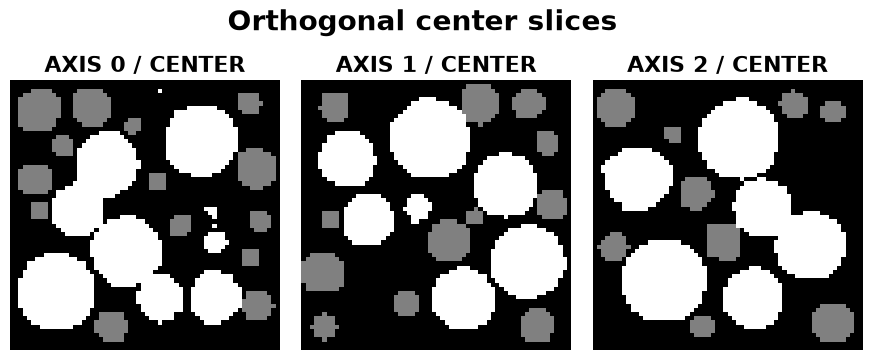

In [5]:
center = options.volume_size // 2
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for axis_id, axis in enumerate(axes):
    axis.imshow(
        volume.select(axis_id, center),
        cmap="gray",
        vmin=0,
        vmax=options.num_phases - 1,
        interpolation="nearest",
    )
    axis.set_title(f"AXIS {axis_id} / CENTER", fontsize=16, fontweight="bold")
    axis.axis("off")
fig.suptitle("Orthogonal center slices", fontsize=20, fontweight="bold")
fig.subplots_adjust(top=0.82, wspace=0.08)
plt.show()

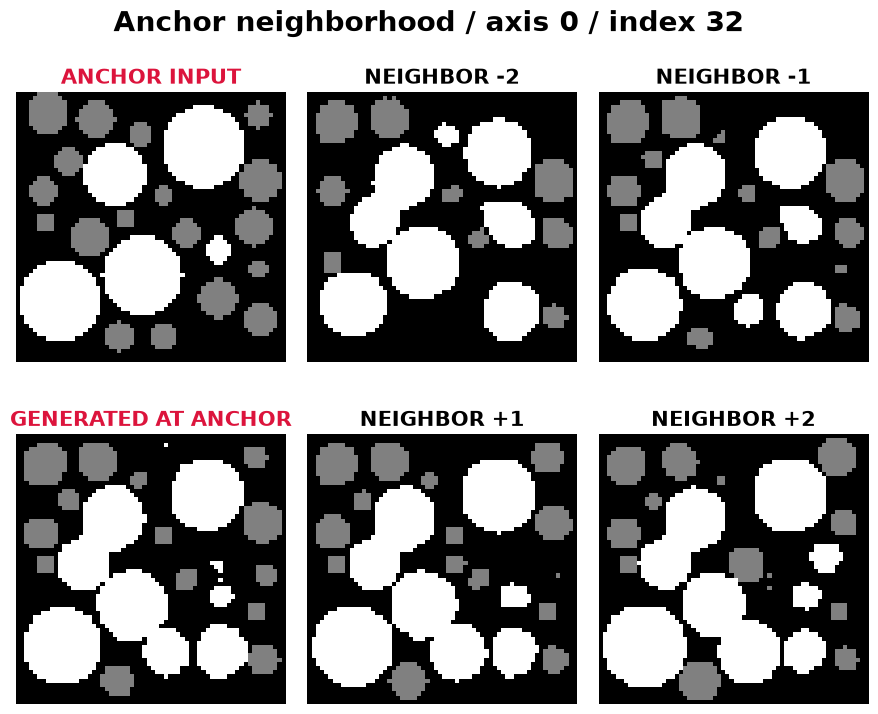

In [6]:
neighbors = [
    volume.select(anchor.axis, anchor.index + offset).numpy()
    for offset in NEIGHBOR_OFFSETS
]
panels = [(anchor.image, "ANCHOR INPUT", True)] + [
    (
        image,
        "GENERATED AT ANCHOR" if offset == 0 else f"NEIGHBOR {offset:+d}",
        offset == 0,
    )
    for offset, image in zip(NEIGHBOR_OFFSETS, neighbors)
]

fig, axes = plt.subplots(2, 3, figsize=(11, 8))
for axis, (image, title, highlighted) in zip(axes.ravel(), panels):
    axis.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=options.num_phases - 1,
        interpolation="nearest",
    )
    axis.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        color="crimson" if highlighted else "black",
    )
    axis.axis("off")
fig.suptitle(
    f"Anchor neighborhood / axis {anchor.axis} / index {anchor.index}",
    fontsize=20,
    fontweight="bold",
)
fig.subplots_adjust(top=0.88, hspace=0.25, wspace=0.08)
plt.show()

In [7]:
%gui qt
import napari

viewer = napari.Viewer(ndisplay=3)
viewer.add_labels(volume.numpy(), name="MPDD volume")
viewer

Viewer(mouse_move_callbacks=[], mouse_wheel_callbacks=[<function dims_scroll at 0x000001D1218107C0>], mouse_drag_callbacks=[<function drag_to_zoom at 0x000001D121810900>], mouse_double_click_callbacks=[<function double_click_to_zoom at 0x000001D121810860>], camera=Camera(center=(31.5, 31.5, 31.5), zoom=8.89140625, angles=(0.0, 0.0, 0.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(1.0, 1.0, 0.0), viewbox=None, scaled=True, size=1.0, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=3, ndisplay=3, order=(0, 1, 2), axis_labels=('-3', '-2', '-1'), rollable=(True, True, True), range=(RangeTuple(start=0.0, stop=63.0, step=1.0), RangeTuple(start=0.0, stop=63.0, step=1.0), RangeTuple(start=0.0, stop=63.0, step=1.0)), margin_left=(0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0), point=(31.0, 31.0, 31.0), units=(<Unit('p